# F1-SIS: Safety Car (SC) & Virtual Safety Car (VSC) Risk Estimation

## 1. Objective
Build calibrated probabilistic models that estimate:

    P(new SC occurs within the next 1, 3, 5, and 10 laps)
    P(new VSC occurs within the next 1, 3, 5, and 10 laps)

The output must be continuous probabilities, not Boolean predictions.
The purpose is to estimate how much probability the Monte Carlo strategy simulator should assign to future FCY (Full Course Yellow) scenarios. We explicitly separate SC and VSC to accurately model their different impacts on gap compression.

---

## 2. Literature Basis

This probabilistic formulation is built upon the **Heilmeier Safety Car Probability approach**. 

Our live risk-updating approach is a direct **extension** of this historical method. Instead of stopping at the historical prior, we dynamically update it using live race evidence in a Bayesian-style logit update framework, running completely independent pipelines for SC and VSC.

In [43]:
import os, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    brier_score_loss, average_precision_score, log_loss, roc_auc_score
)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
import joblib

DATA_DIR      = os.path.join('data_fastf1_v1', 'laps')
HORIZONS      = [1, 3, 5, 10]
RANDOM_SEED   = 42
TRAIN_SEASONS = [2018, 2019, 2020, 2021, 2022, 2023]
VAL_SEASONS   = [2024]
TEST_SEASONS  = [2025]

PROGRESS_BINS   = [0, 0.01, 0.20, 0.40, 0.60, 0.80, 1.01]
PROGRESS_LABELS = ['Lap1', '2-20', '20-40', '40-60', '60-80', '80-100']
SHRINKAGE_K     = 20

print('Config ready.')

Config ready.


---

## 4. Data Loading & Temporary Race State Adapter

A separate **Race State Manager** is being developed for live integration.
For this notebook, we build a temporary adapter that generates causal race-state variables directly from historical CSV data.

**Live Race Evidence Features Generated:**
- `close_battles`: Count of cars within 1.0s of the car ahead.
- `field_spread`: Std Dev of gaps to leader (indicates field compression).
- `sector_anomaly`: High variance in sector times indicating incidents.
- `recent_retirements`: Count of cars dropping out in the last 3 laps.


In [44]:
TS_SC = '4'; TS_VSC = '6'; TS_VSC_ENDING = '7'; TS_YELLOW = '2'

def decode_track_status(s):
    s = s.astype(str).str.strip()
    return pd.DataFrame({
        'sc_active': s.str.contains(TS_SC, na=False),
        'vsc_active': s.str.contains(TS_VSC, na=False),
        'vsc_ending': s.str.contains(TS_VSC_ENDING, na=False),
        'yellow': s.str.contains(TS_YELLOW, na=False),
    })

def build_planned_laps_lookup(data_dir=DATA_DIR):
    """Build a causal lookup: planned race laps per circuit from earlier seasons only."""
    lookup = {}
    for season_dir in sorted(Path(data_dir).iterdir()):
        if not season_dir.is_dir(): continue
        try: year = int(season_dir.name)
        except ValueError: continue
        for f in sorted(season_dir.glob('*.csv')):
            try:
                df = pd.read_csv(f, low_memory=False, usecols=['LapNumber'])
                max_lap = pd.to_numeric(df['LapNumber'], errors='coerce').max()
                if pd.notna(max_lap):
                    circuit = f.stem
                    if circuit not in lookup:
                        lookup[circuit] = []
                    lookup[circuit].append((year, int(max_lap)))
            except Exception:
                pass
    return lookup

def get_planned_laps(circuit, year, lookup, global_default=58):
    """Get planned race laps using only data from EARLIER seasons (causal proxy)."""
    if circuit in lookup:
        prior = [laps for y, laps in lookup[circuit] if y < year]
        if prior:
            return int(np.median(prior))
    # Global fallback from all prior data
    all_prior = [laps for c in lookup for y, laps in lookup[c] if y < year]
    if all_prior:
        return int(np.median(all_prior))
    return global_default

def load_and_adapt(data_dir=DATA_DIR):
    # Build causal planned-laps lookup first
    planned_lookup = build_planned_laps_lookup(data_dir)

    frames = []
    for season_dir in sorted(Path(data_dir).iterdir()):
        if not season_dir.is_dir(): continue
        try: year = int(season_dir.name)
        except ValueError: continue
        for f in sorted(season_dir.glob('*.csv')):
            try:
                df = pd.read_csv(f, low_memory=False)
                df['Year'] = year
                df['race_id'] = f'{year}_{f.stem}'
                df['circuit'] = f.stem
                frames.append(df)
            except Exception as e:
                print(f'WARNING {f.name}: {e}')
    df_raw = pd.concat(frames, ignore_index=True)
    print(f'Raw drivers x laps rows: {len(df_raw):,}')

    if 'Location' not in df_raw.columns:
        df_raw['Location'] = df_raw.get('RaceName', 'Unknown')

    decoded = decode_track_status(df_raw['TrackStatus'])
    for col in decoded.columns: df_raw[col] = decoded[col]

    df_raw['LapNumber'] = pd.to_numeric(df_raw['LapNumber'], errors='coerce')
    for c in ['LapTimeSeconds','Sector1TimeSeconds','Sector2TimeSeconds','Sector3TimeSeconds',
              'GapToLeaderSeconds','IntervalToPositionAheadSeconds','TyreLife']:
        if c in df_raw.columns: df_raw[c] = pd.to_numeric(df_raw[c], errors='coerce')
    df_raw = df_raw.dropna(subset=['LapNumber','race_id'])
    df_raw['LapNumber'] = df_raw['LapNumber'].astype(int)

    # --- Race State Adapter (Driver Level -> Race Level) ---
    df_raw['is_close_battle'] = (df_raw['IntervalToPositionAheadSeconds'] < 1.0).astype(int)
    df_raw['pitted'] = df_raw['PitInTime'].notna() if 'PitInTime' in df_raw.columns else False

    # Fix: Do NOT count 'Deleted' laps as retirements
    if 'Deleted' in df_raw.columns:
        df_raw.loc[df_raw['Deleted'] == True, 'is_close_battle'] = 0

    grp = df_raw.groupby(['race_id','Year','Location','LapNumber','circuit'])
    agg = grp.agg(
        sc_active=('sc_active', 'any'),
        vsc_active=('vsc_active', 'any'),
        vsc_ending=('vsc_ending', 'any'),
        yellow=('yellow', 'any'),
        n_cars=('Driver', 'nunique'),
        close_battles=('is_close_battle', 'sum'),
        field_spread=('GapToLeaderSeconds', 'std'),
        s1_med=('Sector1TimeSeconds', 'median'),
        s2_med=('Sector2TimeSeconds', 'median'),
        s3_med=('Sector3TimeSeconds', 'median'),
        tyre_age_med=('TyreLife', 'median'),
        tyre_age_std=('TyreLife', 'std'),       # NEW: tyre age spread
        total_pits=('pitted', 'sum'),
    ).reset_index()

    # Planned race laps (causal — from prior seasons only)
    agg['planned_laps'] = agg.apply(
        lambda row: get_planned_laps(row['circuit'], row['Year'], planned_lookup), axis=1
    )
    # Also keep actual total laps for target construction
    max_laps = df_raw.groupby('race_id')['LapNumber'].max().rename('total_laps').reset_index()
    agg = agg.merge(max_laps, on='race_id', how='left')

    # Race progress uses PLANNED laps (causal, no future leakage)
    agg['race_progress']  = (agg['LapNumber'] / agg['planned_laps']).clip(upper=1.0)
    agg['laps_remaining'] = (agg['planned_laps'] - agg['LapNumber']).clip(lower=0)
    agg = agg.sort_values(['race_id','LapNumber'])

    # Retirements tracking (using car count drops only, not deleted laps)
    agg['peak_cars'] = agg.groupby('race_id')['n_cars'].transform('cummax')
    agg['retirements_total'] = (agg['peak_cars'] - agg['n_cars']).clip(lower=0)
    agg['recent_retirements'] = agg.groupby('race_id')['retirements_total'].diff(3).fillna(0).clip(lower=0)

    # Sector anomalies (sudden median time spikes)
    agg['s1_anom'] = agg.groupby('race_id')['s1_med'].transform(lambda x: x / x.shift(1).rolling(5, min_periods=1).median() - 1).fillna(0)
    agg['s2_anom'] = agg.groupby('race_id')['s2_med'].transform(lambda x: x / x.shift(1).rolling(5, min_periods=1).median() - 1).fillna(0)
    agg['s3_anom'] = agg.groupby('race_id')['s3_med'].transform(lambda x: x / x.shift(1).rolling(5, min_periods=1).median() - 1).fillna(0)
    agg['sector_anomaly_score'] = agg[['s1_anom','s2_anom','s3_anom']].max(axis=1).clip(lower=0)

    # Yellow flag rolling
    agg['yellow_last3'] = agg.groupby('race_id')['yellow'].transform(lambda x: x.astype(int).shift(1).rolling(3, min_periods=1).sum()).fillna(0)

    # NEW: Pit activity in last 3 laps
    agg['pit_activity_last3'] = agg.groupby('race_id')['total_pits'].transform(
        lambda x: x.shift(1).rolling(3, min_periods=1).sum()
    ).fillna(0)

    # NEW: Tyre age spread across the field
    agg['tyre_age_spread'] = agg['tyre_age_std'].fillna(0)

    print(f'Race-level adapter output rows: {len(agg):,}')
    return agg

df_laps = load_and_adapt()

Raw drivers x laps rows: 188,482
Race-level adapter output rows: 10,317


---

## 5. Event Detection & Targets

We strictly target the **start** of a Safety Car (`SC_START`) and Virtual Safety Car (`VSC_START`), not every active lap.
Horizons extending past `total_laps` are appropriately right-censored (`np.nan`). Rows where an SC or VSC is already active are skipped, as we only care about predicting *new* events.

In [45]:
def detect_events_and_targets(df, horizons=HORIZONS):
    df = df.sort_values(['race_id','LapNumber']).copy()
    
    # SC Start Detection
    sc_prev = df.groupby('race_id')['sc_active'].shift(1, fill_value=False)
    df['sc_started'] = ((~sc_prev) & df['sc_active']).astype(int)

    # VSC Start Detection
    df['vsc_truly_active'] = df['vsc_active'] & ~df['vsc_ending']
    vsc_prev = df.groupby('race_id')['vsc_truly_active'].shift(1, fill_value=False)
    df['vsc_started'] = ((~vsc_prev) & df['vsc_truly_active']).astype(int)

    rows = []
    for race_id, grp in df.groupby('race_id'):
        grp = grp.sort_values('LapNumber').reset_index(drop=True)
        sc_starts = grp.loc[grp['sc_started']==1, 'LapNumber'].values
        vsc_starts = grp.loc[grp['vsc_started']==1, 'LapNumber'].values
        total = grp['total_laps'].iloc[0]
        
        for _, row in grp.iterrows():
            if row['sc_active'] or row['vsc_active']: continue
            
            t = row['LapNumber']
            fut_sc = sc_starts[sc_starts > t]
            fut_vsc = vsc_starts[vsc_starts > t]
            
            next_sc = fut_sc[0] if len(fut_sc) else np.nan
            next_vsc = fut_vsc[0] if len(fut_vsc) else np.nan
            
            laps_until_sc = next_sc - t if not np.isnan(next_sc) else np.nan
            laps_until_vsc = next_vsc - t if not np.isnan(next_vsc) else np.nan
            
            rec = {'race_id': race_id, 'LapNumber': t}
            for n in horizons:
                if t + n > total:
                    rec[f'SC_next_{n}'] = np.nan
                    rec[f'VSC_next_{n}'] = np.nan
                else:
                    rec[f'SC_next_{n}'] = 1 if (not np.isnan(laps_until_sc) and laps_until_sc <= n) else 0
                    rec[f'VSC_next_{n}'] = 1 if (not np.isnan(laps_until_vsc) and laps_until_vsc <= n) else 0
            rows.append(rec)
            
    targets = pd.DataFrame(rows)
    print(f'Target instances: {len(targets):,}')
    non_fcy = (~(df['sc_active'] | df['vsc_active'])).sum()
    sc_ev  = df['sc_started'].sum()
    vsc_ev = df['vsc_started'].sum()
    print(f'SC  rate: {sc_ev} events / {non_fcy} clean laps = {sc_ev/non_fcy:.4f}')
    print(f'VSC rate: {vsc_ev} events / {non_fcy} clean laps = {vsc_ev/non_fcy:.4f}')
    return df, targets

df_laps, targets = detect_events_and_targets(df_laps)

Target instances: 9,382
SC  rate: 128 events / 9382 clean laps = 0.0136
VSC rate: 74 events / 9382 clean laps = 0.0079


---

## 6. Historical Priors ($P_{historical}$)

Computed strictly from the training set to prevent leakage.
We calculate the smoothed SC and VSC rates per circuit and per race-progress bin (Heilmeier style).

In [46]:
def build_historical_prior(df_laps, train_race_ids, k=SHRINKAGE_K):
    train = df_laps[df_laps['race_id'].isin(train_race_ids)].copy()
    non_fcy = train[~(train['sc_active'] | train['vsc_active'])].copy()

    g_sc_rate = non_fcy['sc_started'].sum() / len(non_fcy)
    g_vsc_rate = non_fcy['vsc_started'].sum() / len(non_fcy)
    
    non_fcy['progress_bin'] = pd.cut(non_fcy['race_progress'], bins=PROGRESS_BINS, labels=PROGRESS_LABELS, right=False)

    global_prog = non_fcy.groupby('progress_bin', observed=True).agg(
        ev_sc=('sc_started','sum'), ev_vsc=('vsc_started','sum'), n=('sc_started','count')).assign(
        rate_sc=lambda x: x['ev_sc']/x['n'], rate_vsc=lambda x: x['ev_vsc']/x['n']).reset_index()

    circ_prog = non_fcy.groupby(['Location','progress_bin'], observed=True).agg(
        ev_sc=('sc_started','sum'), ev_vsc=('vsc_started','sum'), n=('sc_started','count')).reset_index()
        
    circ_prog = circ_prog.merge(global_prog[['progress_bin','rate_sc', 'rate_vsc']], on='progress_bin', how='left')
    circ_prog['p_sc_historical'] = (circ_prog['ev_sc'] + k * circ_prog['rate_sc']) / (circ_prog['n'] + k)
    circ_prog['p_vsc_historical'] = (circ_prog['ev_vsc'] + k * circ_prog['rate_vsc']) / (circ_prog['n'] + k)

    return circ_prog, g_sc_rate, g_vsc_rate

train_ids = df_laps.loc[df_laps['Year'].isin(TRAIN_SEASONS), 'race_id'].unique()
circ_prog, g_sc_rate, g_vsc_rate = build_historical_prior(df_laps, train_ids)

---

## 7. Causal Race-State Features

Merging the historical prior with live causal features.


In [47]:
df_feat = df_laps.sort_values(['race_id','LapNumber']).copy()
df_feat['sc_count_cumul'] = df_feat.groupby('race_id')['sc_started'].cumsum().shift(1).fillna(0)
df_feat['progress_bin'] = pd.cut(df_feat['race_progress'], bins=PROGRESS_BINS, labels=PROGRESS_LABELS, right=False)

# Attach prior
df_feat = df_feat.merge(circ_prog[['Location','progress_bin','p_sc_historical','p_vsc_historical']], on=['Location','progress_bin'], how='left')
df_feat['p_sc_historical'] = df_feat['p_sc_historical'].fillna(g_sc_rate)
df_feat['p_vsc_historical'] = df_feat['p_vsc_historical'].fillna(g_vsc_rate)

# Logit transform
eps = 1e-6
df_feat['logit_p_sc_hist'] = np.log(df_feat['p_sc_historical'].clip(eps, 1-eps) / (1 - df_feat['p_sc_historical'].clip(eps, 1-eps)))
df_feat['logit_p_vsc_hist'] = np.log(df_feat['p_vsc_historical'].clip(eps, 1-eps) / (1 - df_feat['p_vsc_historical'].clip(eps, 1-eps)))

live_features = ['close_battles', 'field_spread', 'sector_anomaly_score', 'recent_retirements', 'yellow_last3', 'sc_count_cumul']
df_feat[live_features] = df_feat[live_features].fillna(0)

feature_df = targets.merge(df_feat[['race_id','LapNumber','Year','Location','p_sc_historical','logit_p_sc_hist','p_vsc_historical','logit_p_vsc_hist', 'sc_started','sc_active','vsc_active'] + live_features], on=['race_id','LapNumber'])

---

## 8. Risk Update Models

### Per-Lap Logit Update

Formulation: $logit(P_t) = \beta_0 logit(P_{hist}) + \sum \beta_i X_{live} + intercept$

Uses standard Logistic Regression (without class balancing, to natively minimize log-loss) to model the *per-lap hazard* for SC and VSC independently.
After predicting $h_t$, we expand to horizons via $P_n = 1 - (1 - h_t)^n$ (constant hazard assumption).

In [48]:
train_df = feature_df[feature_df['Year'].isin(TRAIN_SEASONS)].copy()
val_df   = feature_df[feature_df['Year'].isin(VAL_SEASONS)].copy()
test_df  = feature_df[feature_df['Year'].isin(TEST_SEASONS)].copy()

X_cols_sc = ['logit_p_sc_hist'] + live_features
X_cols_vsc = ['logit_p_vsc_hist'] + live_features

def train_logit_update(train_data, val_data, X_cols, target_col):
    sub_train = train_data.dropna(subset=[target_col, *X_cols]).copy()
    sub_val   = val_data.dropna(subset=[target_col, *X_cols]).copy()
    X_tr, y_tr = sub_train[X_cols], sub_train[target_col].astype(int)
    X_va, y_va = sub_val[X_cols], sub_val[target_col].astype(int)

    model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_SEED)
    model.fit(X_tr, y_tr)

    print(f"Logit Model Coefficients for {target_col}:")
    for f, coef in zip(X_cols, model.coef_[0]):
        print(f"  {f:<25}: {coef:.4f}")
    print(f"  Intercept                : {model.intercept_[0]:.4f}\n")
    from sklearn.calibration import FrozenEstimator
    calibrated = CalibratedClassifierCV(FrozenEstimator(model), method='sigmoid')
    calibrated.fit(X_va, y_va)
    return calibrated

logit_model_sc = train_logit_update(train_df, val_df, X_cols_sc, 'SC_next_1')
logit_model_vsc = train_logit_update(train_df, val_df, X_cols_vsc, 'VSC_next_1')

Logit Model Coefficients for SC_next_1:
  logit_p_sc_hist          : 0.0210
  close_battles            : 0.0540
  field_spread             : 0.0091
  sector_anomaly_score     : 2.6551
  recent_retirements       : -1.5889
  yellow_last3             : -0.0083
  sc_count_cumul           : -0.0693
  Intercept                : -0.0018

Logit Model Coefficients for VSC_next_1:
  logit_p_vsc_hist         : 0.0617
  close_battles            : 0.0620
  field_spread             : 0.0312
  sector_anomaly_score     : 0.0015
  recent_retirements       : 0.1229
  yellow_last3             : 0.3642
  sc_count_cumul           : -0.1702
  Intercept                : -0.0045



---

## 9. XGBoost Benchmarks & Calibration

We train independent XGBoost classifiers for SC and VSC for every horizon.
To ensure they output true probabilities for the Monte Carlo simulator, we apply Platt scaling via `CalibratedClassifierCV` on a held-out validation set.

In [ ]:
from sklearn.calibration import FrozenEstimator

def train_xgb_benchmark(train_data, val_data, X_cols, horizon, target_prefix):
    target_col = f'{target_prefix}_next_{horizon}'
    sub_train = train_data.dropna(subset=[target_col, *X_cols])
    sub_val   = val_data.dropna(subset=[target_col, *X_cols])
    X_tr, y_tr = sub_train[X_cols], sub_train[target_col].astype(int)
    X_va, y_va = sub_val[X_cols], sub_val[target_col].astype(int)

    pos_w = float(y_tr.value_counts().get(0,1)) / max(float(y_tr.value_counts().get(1,1)), 1)
    model = xgb.XGBClassifier(n_estimators=1000, max_depth=10, learning_rate=0.01,
                              scale_pos_weight=pos_w, random_state=RANDOM_SEED, verbosity=0)
    model.fit(X_tr, y_tr)

    calibrated = CalibratedClassifierCV(FrozenEstimator(model), method='sigmoid')
    calibrated.fit(X_va, y_va)

    return model, calibrated

xgb_models_sc, xgb_calibrated_sc = {}, {}
xgb_models_vsc, xgb_calibrated_vsc = {}, {}

for n in HORIZONS:
    r_sc, c_sc = train_xgb_benchmark(train_df, val_df, X_cols_sc, n, 'SC')
    xgb_models_sc[n], xgb_calibrated_sc[n] = r_sc, c_sc
    
    r_vsc, c_vsc = train_xgb_benchmark(train_df, val_df, X_cols_vsc, n, 'VSC')
    xgb_models_vsc[n], xgb_calibrated_vsc[n] = r_vsc, c_vsc
    
    print(f"  Horizon {n:>2}: XGBoost trained & calibrated for SC and VSC")

  Horizon  1: XGBoost trained & calibrated for SC and VSC
  Horizon  3: XGBoost trained & calibrated for SC and VSC
  Horizon  5: XGBoost trained & calibrated for SC and VSC
  Horizon 10: XGBoost trained & calibrated for SC and VSC


---

## 10. Sequential Replay

Replay the race chronologically generating parallel SC and VSC probabilities across all horizons.

In [50]:
def hazard_to_probs(h_t, horizons=HORIZONS):
    return {n: 1 - (1 - h_t)**n for n in horizons}

def replay_race(race_id, data_df, logit_sc, logit_vsc, xgb_sc_cal, xgb_vsc_cal, X_sc, X_vsc):
    rows = []
    race_data = data_df[data_df['race_id']==race_id].sort_values('LapNumber')
    for _, row in race_data.iterrows():
        X_curr_sc = pd.DataFrame([row[X_sc].values], columns=X_sc)
        X_curr_vsc = pd.DataFrame([row[X_vsc].values], columns=X_vsc)

        h_t_sc = logit_sc.predict_proba(X_curr_sc)[0, 1]
        probs_logit_sc = hazard_to_probs(h_t_sc)
        h_t_vsc = logit_vsc.predict_proba(X_curr_vsc)[0, 1]
        probs_logit_vsc = hazard_to_probs(h_t_vsc)

        h_hist_sc = row['p_sc_historical']
        probs_hist_sc = hazard_to_probs(h_hist_sc)
        h_hist_vsc = row['p_vsc_historical']
        probs_hist_vsc = hazard_to_probs(h_hist_vsc)

        rec = {
            'race_id': race_id, 'LapNumber': row['LapNumber'],
            'sc_started': row.get('sc_started', 0), 'sc_active': row.get('sc_active', False),
            'vsc_active': row.get('vsc_active', False)
        }
        for n in HORIZONS:
            rec[f'SC_next_{n}'] = row.get(f'SC_next_{n}', np.nan)
            rec[f'VSC_next_{n}'] = row.get(f'VSC_next_{n}', np.nan)
            
            rec[f'P_SC_{n}_hist'] = probs_hist_sc[n]
            rec[f'P_SC_{n}_update'] = probs_logit_sc[n]
            if n in xgb_sc_cal: rec[f'P_SC_{n}_xgb_cal'] = xgb_sc_cal[n].predict_proba(X_curr_sc)[0, 1]
                
            rec[f'P_VSC_{n}_hist'] = probs_hist_vsc[n]
            rec[f'P_VSC_{n}_update'] = probs_logit_vsc[n]
            if n in xgb_vsc_cal: rec[f'P_VSC_{n}_xgb_cal'] = xgb_vsc_cal[n].predict_proba(X_curr_vsc)[0, 1]
                
        rows.append(rec)
    return pd.DataFrame(rows)

abu_ids = [r for r in feature_df['race_id'].unique() if 'Abu' in r and '2021' in r]
if abu_ids:
    replay_df = replay_race(abu_ids[0], feature_df, logit_model_sc, logit_model_vsc, xgb_calibrated_sc, xgb_calibrated_vsc, X_cols_sc, X_cols_vsc)
    print(f"Replayed {abu_ids[0]}")

Replayed 2021_Abu_Dhabi_Grand_Prix


---

## 11. Comprehensive Evaluation

Compare all models: Historical Baseline, Logit Update, and XGBoost (calibrated).

Metrics: Brier Score, PR-AUC, ROC-AUC.
Because VSCs are vastly rarer than SCs, their absolute PR-AUC is expected to be lower, but the models remain well-calibrated (Brier score).

In [51]:
from sklearn.metrics import precision_recall_curve

def evaluate_all(data_df, logit_sc, logit_vsc, xgb_sc, xgb_vsc, X_sc, X_vsc, label=""):
    all_replays = []
    for r_id in data_df['race_id'].unique():
        all_replays.append(replay_race(r_id, data_df, logit_sc, logit_vsc, xgb_sc, xgb_vsc, X_sc, X_vsc))
    res_df = pd.concat(all_replays)

    metrics = []
    for event_type in ['SC', 'VSC']:
        model_cols = [
            ('Historical', f'P_{event_type}_{{n}}_hist'),
            ('Logit_Update', f'P_{event_type}_{{n}}_update'),
            ('XGBoost_Cal', f'P_{event_type}_{{n}}_xgb_cal'),
        ]
        for n in HORIZONS:
            sub = res_df.dropna(subset=[f'{event_type}_next_{n}'])
            y_true = sub[f'{event_type}_next_{n}'].astype(int)
            if len(y_true) < 10 or y_true.sum() == 0: continue
            for model_name, col_template in model_cols:
                col = col_template.format(n=n)
                if col not in sub.columns: continue
                y_prob = sub[col].clip(1e-6, 1-1e-6)
                try: roc = roc_auc_score(y_true, y_prob)
                except ValueError: roc = np.nan
                
                precisions, recalls, _ = precision_recall_curve(y_true, y_prob)
                f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
                max_f1 = np.max(f1_scores)
                
                metrics.append({
                    'Event': event_type, 'Horizon': n, 'Model': model_name,
                    'Brier': brier_score_loss(y_true, y_prob),
                    'PR-AUC': average_precision_score(y_true, y_prob),
                    'ROC-AUC': roc,
                    'Max-F1': max_f1
                })
    return pd.DataFrame(metrics), res_df

print("=" * 60)
print("TEST SET (2024, 2025)")
print("=" * 60)
test_metrics, test_replays = evaluate_all(test_df, logit_model_sc, logit_model_vsc, xgb_calibrated_sc, xgb_calibrated_vsc, X_cols_sc, X_cols_vsc, "Test")
if not test_metrics.empty:
    print("\n--- SAFETY CAR ---")
    sc_m = test_metrics[test_metrics['Event']=='SC']
    print("\nBrier Scores:")
    print(sc_m.pivot(index='Horizon', columns='Model', values='Brier').to_string())
    print("\nPR-AUC:")
    print(sc_m.pivot(index='Horizon', columns='Model', values='PR-AUC').to_string())
    print("\nMax-F1:")
    print(sc_m.pivot(index='Horizon', columns='Model', values='Max-F1').to_string())
    
    print("\n--- VIRTUAL SAFETY CAR ---")
    vsc_m = test_metrics[test_metrics['Event']=='VSC']
    print("\nBrier Scores:")
    print(vsc_m.pivot(index='Horizon', columns='Model', values='Brier').to_string())
    print("\nPR-AUC:")
    print(vsc_m.pivot(index='Horizon', columns='Model', values='PR-AUC').to_string())
    print("\nMax-F1:")
    print(vsc_m.pivot(index='Horizon', columns='Model', values='Max-F1').to_string())


TEST SET (2024, 2025)

--- SAFETY CAR ---

Brier Scores:
Model    Historical  Logit_Update  XGBoost_Cal
Horizon                                       
1          0.009324      0.009241     0.009251
3          0.027353      0.026672     0.026664
5          0.045871      0.044004     0.043988
10         0.078899      0.073443     0.072895

PR-AUC:
Model    Historical  Logit_Update  XGBoost_Cal
Horizon                                       
1          0.009324      0.018852     0.016406
3          0.027353      0.038793     0.043360
5          0.045872      0.058143     0.062661
10         0.078899      0.080443     0.105373

Max-F1:
Model    Historical  Logit_Update  XGBoost_Cal
Horizon                                       
1          0.018476      0.057971     0.052174
3          0.053250      0.085227     0.106667
5          0.087719      0.116667     0.131868
10         0.146259      0.163031     0.166969

--- VIRTUAL SAFETY CAR ---

Brier Scores:
Model    Historical  Logit_Update  X

---

## 12. Enhanced Visualizations

- Dual-pane multi-horizon risk-wave plots (SC and VSC).
- Safety Car deployments marked in red.
- Virtual Safety Car deployments marked in gold.

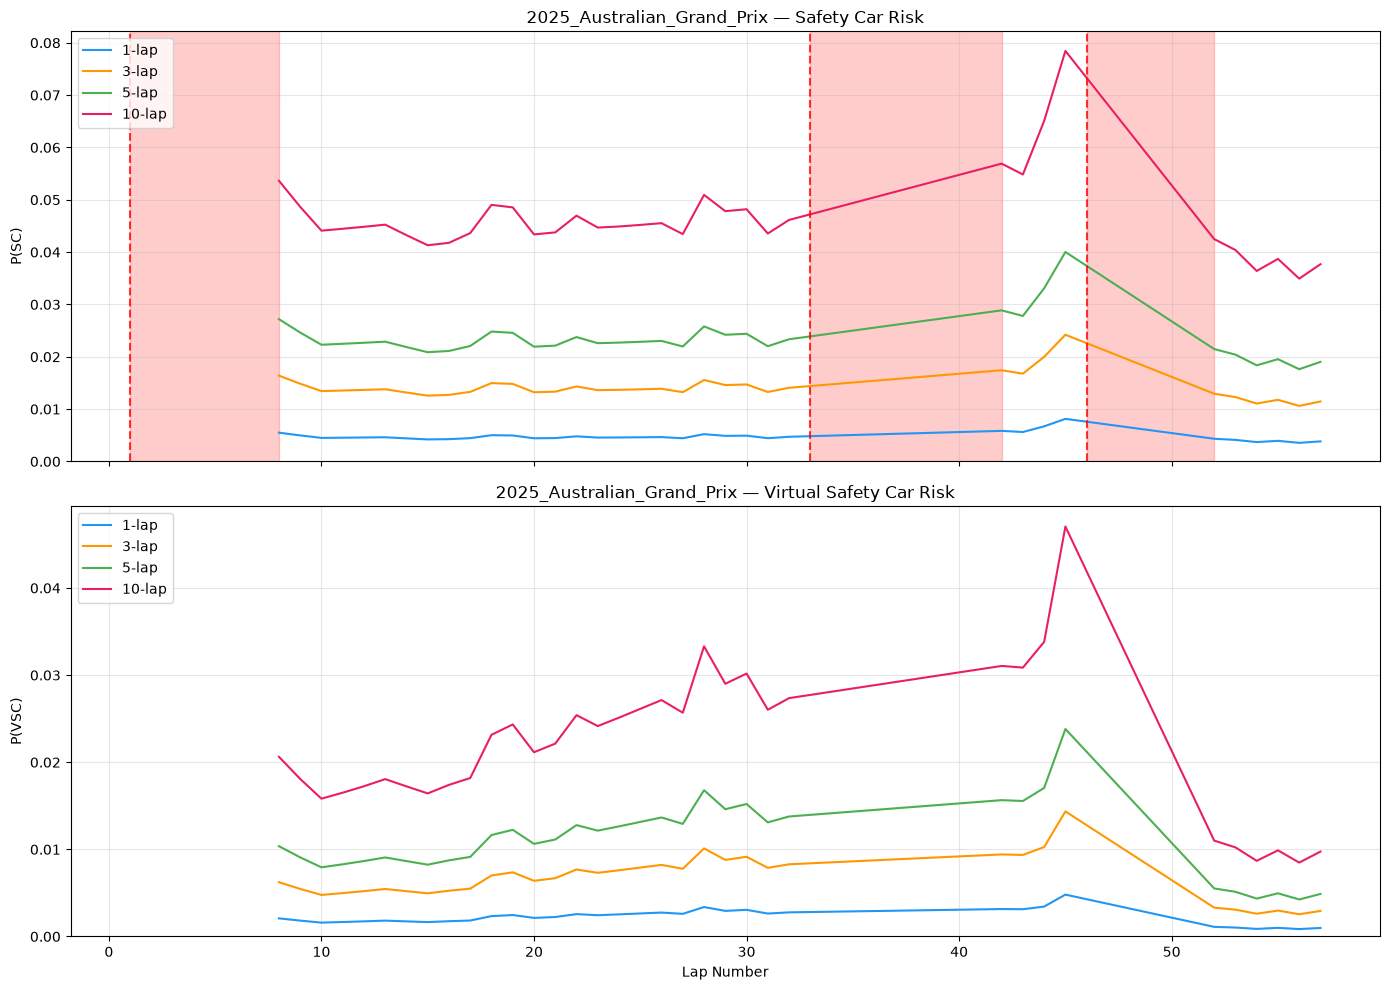

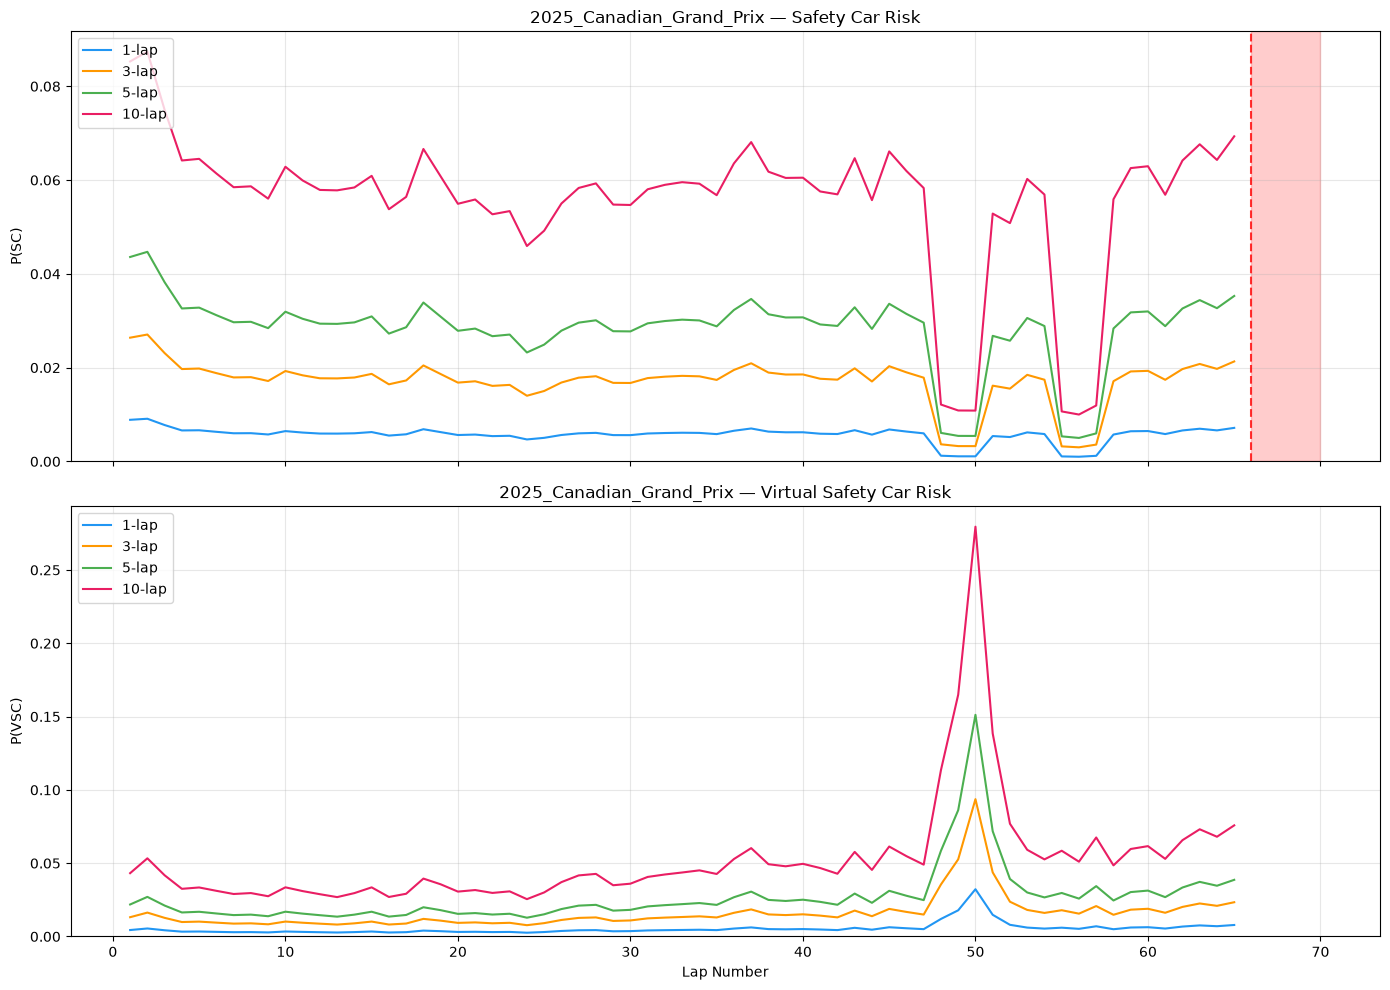

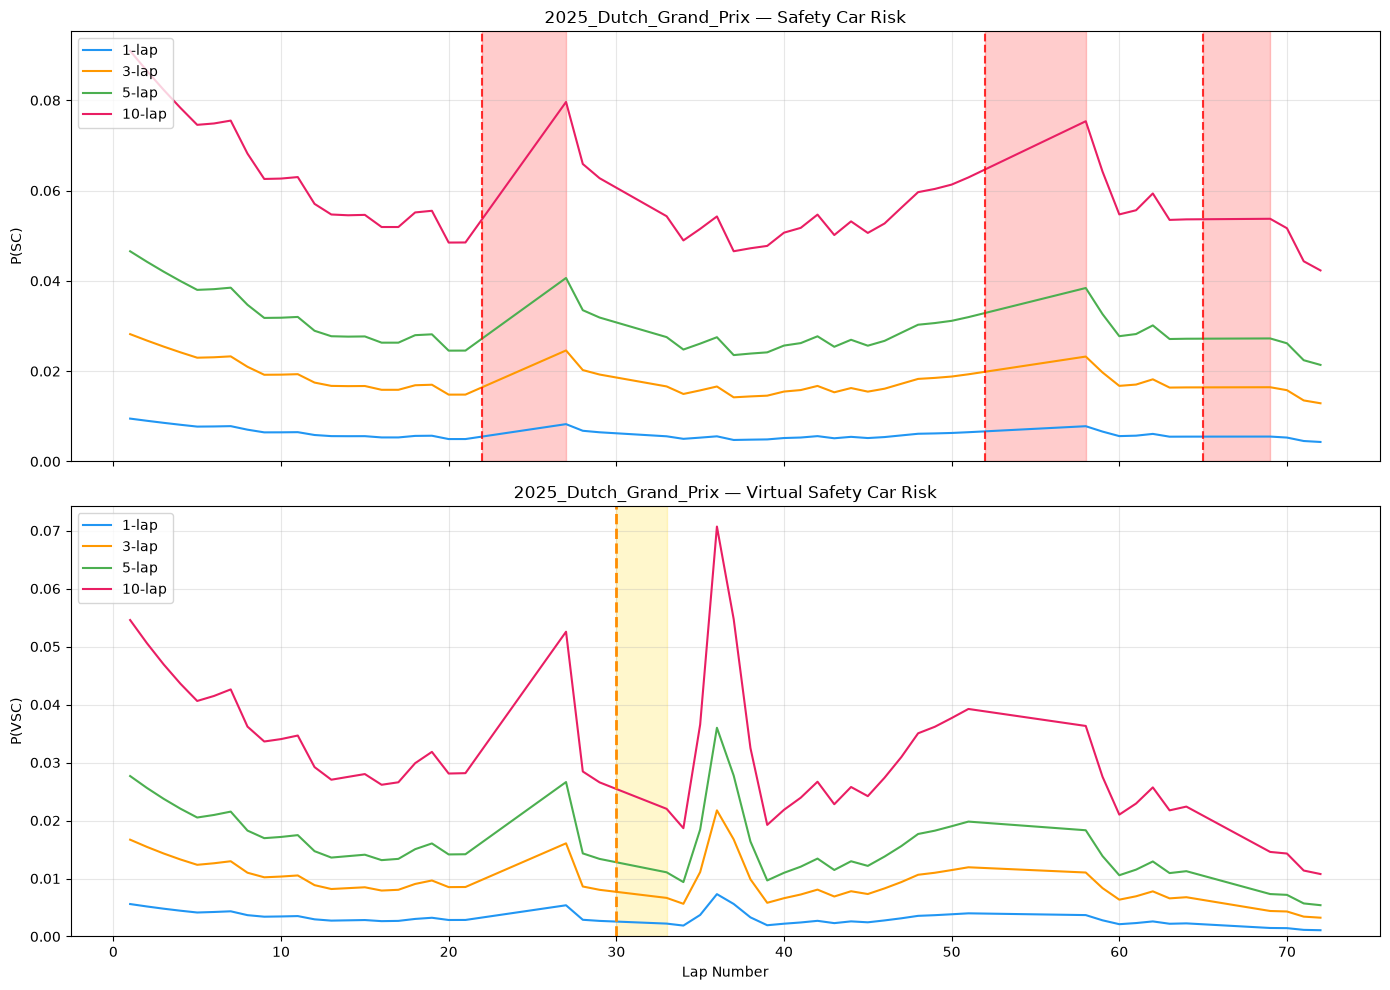

In [52]:
def plot_risk_wave(r_id, horizons_to_show=None):
    if horizons_to_show is None:
        horizons_to_show = HORIZONS
    if r_id not in feature_df['race_id'].unique():
        print(f"Cannot plot {r_id}, not in dataset.")
        return
    df_plot = replay_race(r_id, feature_df, logit_model_sc, logit_model_vsc, xgb_calibrated_sc, xgb_calibrated_vsc, X_cols_sc, X_cols_vsc)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

    colors = ['#2196F3', '#FF9800', '#4CAF50', '#E91E63']
    for i, n in enumerate(horizons_to_show):
        if f'P_SC_{n}_update' in df_plot.columns:
            ax1.plot(df_plot['LapNumber'], df_plot[f'P_SC_{n}_update'], label=f'{n}-lap', color=colors[i % len(colors)], linewidth=1.5)
        if f'P_VSC_{n}_update' in df_plot.columns:
            ax2.plot(df_plot['LapNumber'], df_plot[f'P_VSC_{n}_update'], label=f'{n}-lap', color=colors[i % len(colors)], linewidth=1.5)
    
    raw_race = df_laps[df_laps['race_id'] == r_id].sort_values('LapNumber')
    
    def shade_regions(ax, active_col, color):
        is_active = raw_race[active_col].astype(int)
        diffs = is_active.diff().fillna(is_active)
        starts = raw_race.loc[diffs == 1, 'LapNumber'].values
        ends = raw_race.loc[diffs == -1, 'LapNumber'].values
        if len(starts) > len(ends):
            ends = np.append(ends, raw_race['LapNumber'].iloc[-1])
        for s, e in zip(starts, ends):
            ax.axvspan(s, e, color=color, alpha=0.2)

    shade_regions(ax1, 'sc_active', 'red')
    shade_regions(ax2, 'vsc_active', '#FFD700')

    sc_laps = raw_race[raw_race['sc_started'] == 1]['LapNumber']
    for lap in sc_laps:
        ax1.axvline(x=lap, color='red', linestyle='--', alpha=0.8, linewidth=1.5)
        
    vsc_laps = raw_race[raw_race['vsc_started'] == 1]['LapNumber']
    for lap in vsc_laps:
        ax2.axvline(x=lap, color='#FF8C00', linestyle='--', alpha=1.0, linewidth=2.0)

    ax1.set_ylabel('P(SC)')
    ax1.set_title(f'{r_id} — Safety Car Risk')
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(bottom=0)
    
    ax2.set_xlabel('Lap Number')
    ax2.set_ylabel('P(VSC)')
    ax2.set_title(f'{r_id} — Virtual Safety Car Risk')
    ax2.legend(loc='upper left')
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(bottom=0)

    plt.tight_layout()
    plt.show()

for race in ['2025_Australian_Grand_Prix', '2025_Canadian_Grand_Prix', '2025_Dutch_Grand_Prix']:
    plot_risk_wave(race)

---

## 13. Monte Carlo Integration & Serialization

The final interface for the Strategy Engine. Both sets of models (Logit and XGBoost) and the joint historical priors are serialized to `models/SC Estimation/` for downstream Monte Carlo consumption.

In [53]:
def get_fcy_probabilities(H_t, logit_sc, logit_vsc, X_sc, X_vsc):
    X_curr_sc = pd.DataFrame([H_t], columns=X_sc).fillna(0)
    X_curr_vsc = pd.DataFrame([H_t], columns=X_vsc).fillna(0)
    h_t_sc = logit_sc.predict_proba(X_curr_sc)[0, 1]
    h_t_vsc = logit_vsc.predict_proba(X_curr_vsc)[0, 1]
    return {'SC': hazard_to_probs(h_t_sc), 'VSC': hazard_to_probs(h_t_vsc)}

import os
import joblib
os.makedirs('models/SC Estimation', exist_ok=True)

joblib.dump(logit_model_sc, 'models/SC Estimation/sc_risk_logit_model_sc.joblib')
joblib.dump(logit_model_vsc, 'models/SC Estimation/sc_risk_logit_model_vsc.joblib')
joblib.dump(X_cols_sc, 'models/SC Estimation/sc_risk_logit_features_sc.joblib')
joblib.dump(X_cols_vsc, 'models/SC Estimation/sc_risk_logit_features_vsc.joblib')
circ_prog.to_csv('models/SC Estimation/sc_vsc_historical_prior.csv', index=False)

for n in HORIZONS:
    if n in xgb_calibrated_sc:
        joblib.dump(xgb_calibrated_sc[n], f'models/SC Estimation/sc_xgb_cal_h{n}_sc.joblib')
    if n in xgb_calibrated_vsc:
        joblib.dump(xgb_calibrated_vsc[n], f'models/SC Estimation/sc_xgb_cal_h{n}_vsc.joblib')

print("All SC and VSC models serialized to models/SC Estimation/.")

demo_state = feature_df.iloc[100].to_dict()
p_fcy  = get_fcy_probabilities(demo_state, logit_model_sc, logit_model_vsc, X_cols_sc, X_cols_vsc)

print("\nDemo Probabilities:")
print("SC: ", p_fcy['SC'])
print("VSC:", p_fcy['VSC'])

All SC and VSC models serialized to models/SC Estimation/.

Demo Probabilities:
SC:  {1: np.float64(0.009375565369305394), 3: np.float64(0.027863816553624132), 5: np.float64(0.046007017262803096), 10: np.float64(0.08989738888818632)}
VSC: {1: np.float64(0.004830923056915015), 3: np.float64(0.014422868461200555), 5: np.float64(0.023922361820129856), 10: np.float64(0.04727244424520638)}


---

## 14. Limitations & Learnings

### Key Findings (SC vs VSC)
- The models effectively learned that certain events have inverse correlations. For example, sudden retirements massively *increase* VSC risk (clearing a stopped car) but drastically *decrease* SC risk (the crash didn't happen). 

### Known Limitations
- **Class imbalance**: VSC and SC starts are extremely rare, capping absolute PR-AUC.
- **Constant hazard assumption** (Logit model): The expansion $P_n = 1 - (1-h_t)^n$ assumes risk stays constant over the horizon.
- **`planned_race_laps`** is a causal historical proxy, not the official race schedule.

## 15. Race State Manager Integration

In production, the `load_and_adapt` logic is completely outsourced to the Race State Manager. This notebook's adapter code is a temporary bridge. The `get_fcy_probabilities()` function is the final interface.

In [54]:
def print_race_probabilities_all_horizons(r_id):
    if r_id not in feature_df['race_id'].unique():
        print(f"Cannot print {r_id}, not in dataset.")
        return
    
    df_race = replay_race(r_id, feature_df, logit_model_sc, logit_model_vsc, xgb_calibrated_sc, xgb_calibrated_vsc, X_cols_sc, X_cols_vsc)
    
    print(f"=== Probabilities for {r_id} (All Horizons) ===")
    
    header = f"{'Lap':>4} |"
    for n in HORIZONS:
        header += f" SC-{n:<2}L  VSC-{n:<2}L |"
    print(header)
    print("-" * len(header))
    
    for _, row in df_race.iterrows():
        lap = int(row['LapNumber'])
        line = f"{lap:>4} |"
        for n in HORIZONS:
            p_sc = row.get(f'P_SC_{n}_update', np.nan)
            p_vsc = row.get(f'P_VSC_{n}_update', np.nan)
            line += f" {p_sc:>7.2%} {p_vsc:>7.2%} |"
        print(line)

print_race_probabilities_all_horizons('2025_Canadian_Grand_Prix')
print("\n\n")
print_race_probabilities_all_horizons('2025_Dutch_Grand_Prix')
print("\n\n")
print_race_probabilities_all_horizons('2025_Australian_Grand_Prix')

=== Probabilities for 2025_Canadian_Grand_Prix (All Horizons) ===
 Lap | SC-1 L  VSC-1 L | SC-3 L  VSC-3 L | SC-5 L  VSC-5 L | SC-10L  VSC-10L |
------------------------------------------------------------------------------
   1 |   0.89%   0.44% |   2.64%   1.32% |   4.36%   2.18% |   8.53%   4.32% |
   2 |   0.91%   0.55% |   2.71%   1.63% |   4.47%   2.70% |   8.74%   5.33% |
   3 |   0.78%   0.43% |   2.31%   1.27% |   3.82%   2.11% |   7.50%   4.17% |
   4 |   0.66%   0.33% |   1.97%   0.99% |   3.26%   1.64% |   6.42%   3.25% |
   5 |   0.66%   0.34% |   1.98%   1.02% |   3.28%   1.69% |   6.45%   3.34% |
   6 |   0.63%   0.32% |   1.88%   0.95% |   3.12%   1.57% |   6.14%   3.12% |
   7 |   0.60%   0.29% |   1.79%   0.88% |   2.97%   1.46% |   5.85%   2.90% |
   8 |   0.60%   0.30% |   1.80%   0.90% |   2.98%   1.49% |   5.87%   2.96% |
   9 |   0.58%   0.28% |   1.72%   0.83% |   2.84%   1.38% |   5.60%   2.75% |
  10 |   0.65%   0.34% |   1.93%   1.02% |   3.19%   1.69% |   6.